# Exploratory Data Analysis: Stock Returns & Volatility

This notebook summarizes the dataset and targets for next-day prediction across 14 stocks (6 sectors, 2015 to early 2026). It focuses on what patterns show up in daily returns and volatility using only information available at time t, and on choosing the target, metrics, and time-based validation for the modeling notebook.

Targets:
- **NextDirection**: whether tomorrow’s return is positive
- **NextVolSpike**: whether tomorrow’s volatility exceeds its expanding historical threshold,
  the 80th percentile of past volatility

The main takeaway is that direction looks weak in this dataset, while volatility is persistent
and spikes cluster during market stress.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch
from statsmodels.tsa.stattools import adfuller
from IPython.display import display

# Set global plotting styles and other constants
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Map tickers to their respective sectors
sector_map = {
    "AAPL": "Tech", "MSFT": "Tech", "NVDA": "Tech",
    "GOOGL": "Tech", "AMZN": "Tech", "TSLA": "Tech",
    "JPM": "Finance", 
    "WMT": "Retail",
    "DAL": "Airlines", "UAL": "Airlines",
    "LMT": "Defense", "RTX": "Defense", "NOC": "Defense",
    "XOM": "Energy"
}

# Tol Bright palette (Paul Tol's colorblind-safe scheme) for sectors
sector_colors = {
    "Tech": "#4477AA",      # Blue
    "Finance": "#66CCEE",   # Cyan
    "Retail": "#228833",    # Green
    "Airlines": "#CCBB44",  # Yellow
    "Defense": "#EE6677",   # Red
    "Energy": "#AA3377"     # Purple
}

In [2]:
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

raw_path = ROOT / "data" / "raw" / "merged_features_full.csv"
clean_path = ROOT / "data" / "processed" / "merged_features_clean.csv"

print(f"Raw exists: {raw_path.exists()} -> {raw_path.relative_to(ROOT)}")
print(f"Clean exists: {clean_path.exists()} -> {clean_path.relative_to(ROOT)}")


Raw exists: True -> data/raw/merged_features_full.csv
Clean exists: True -> data/processed/merged_features_clean.csv


## Data Snapshot

The dataset includes daily returns, technical indicators, and VIX data aligned for next-day prediction:
- **Full dataset**: Starts January 2015, retains price history for calculations
- **Clean dataset**: Starts July 2015, removes rows with missing features

Together they cover over 37,000 model-ready rows (ticker-days) across 14 tickers in six sectors, spanning 2,780 trading dates in the full file (2,643 in the clean one).


In [3]:
df_full = pd.read_csv(raw_path, parse_dates=["Date"])
df = pd.read_csv(clean_path, parse_dates=["Date"])


In [4]:
# Compact data snapshot
full_range = (df_full['Date'].min().date(), df_full['Date'].max().date())
clean_range = (df['Date'].min().date(), df['Date'].max().date())
rows_full = len(df_full)
rows_clean = len(df)
rows_lost = rows_full - rows_clean
tickers = df['Ticker'].nunique()

snapshot = pd.DataFrame({
    'Metric': ['Date range (full)', 'Date range (clean)', 'Tickers', 'Rows (full)', 'Rows (clean)', 'Rows lost'],
    'Value': [f"{full_range[0]} to {full_range[1]}", f"{clean_range[0]} to {clean_range[1]}", tickers, rows_full, rows_clean, rows_lost]
})

print(snapshot.to_string(index=False))

            Metric                    Value
 Date range (full) 2015-01-02 to 2026-01-22
Date range (clean) 2015-07-20 to 2026-01-21
           Tickers                       14
       Rows (full)                    38920
      Rows (clean)                    37002
         Rows lost                     1918



## Coverage
| Sector | Tickers |
| :--- | :--- |
| Technology | AAPL, MSFT, NVDA, GOOGL, AMZN, TSLA |
| Finance | JPM |
| Retail | WMT |
| Defense | LMT, RTX, NOC |
| Energy | XOM |
| Airlines | DAL, UAL |


## Market Environment

This section checks return stationarity and distribution shape, cross-ticker co-movement, and
how volatility levels vary by ticker and sector. Volatility persistence and the timing of spike
clusters come later, under Target Selection and Crisis Period Analysis.


### Stationarity Check


In [5]:
adf_results = []

for ticker in sorted(df["Ticker"].unique()):
    ticker_data = df[df["Ticker"] == ticker].sort_values("Date")
    returns = ticker_data["Return"].dropna()
    if len(returns) > 50:
        # Test for unit root, p < 0.05 rejects H0, consistent with stationarity
        adf_stat, p_value, _, _, _, _ = adfuller(returns, autolag="AIC", regression="c")
        adf_results.append({"Ticker": ticker, "ADF Statistic": adf_stat, "P-Value": p_value})

adf_df = pd.DataFrame(adf_results)


print("Augmented Dickey-Fuller Test (H0: unit root)")
display(adf_df.style.format({"ADF Statistic": "{:.3f}", "P-Value": "{:.2e}"}))
print(f"All {len(adf_df)} tickers stationary (p < 0.05), median p = {adf_df['P-Value'].median():.2e}")

Augmented Dickey-Fuller Test (H0: unit root)


,Ticker,ADF Statistic,P-Value
0,AAPL,-16.602,1.76e-29
1,AMZN,-52.506,0.00e+00
2,DAL,-19.014,0.00e+00
3,GOOGL,-17.451,4.65e-30
4,JPM,-14.916,1.43e-27
5,LMT,-18.098,2.56e-30
6,MSFT,-17.535,4.22e-30
7,NOC,-19.284,0.00e+00
8,NVDA,-18.443,2.16e-30
9,RTX,-14.138,2.27e-26


All 14 tickers stationary (p < 0.05), median p = 3.39e-30


Since the modeling task is based on returns (not raw prices), it helps to check whether returns behave more like a stable series than prices do. The ADF results support using returns-based features and targets.


### Return Distributions


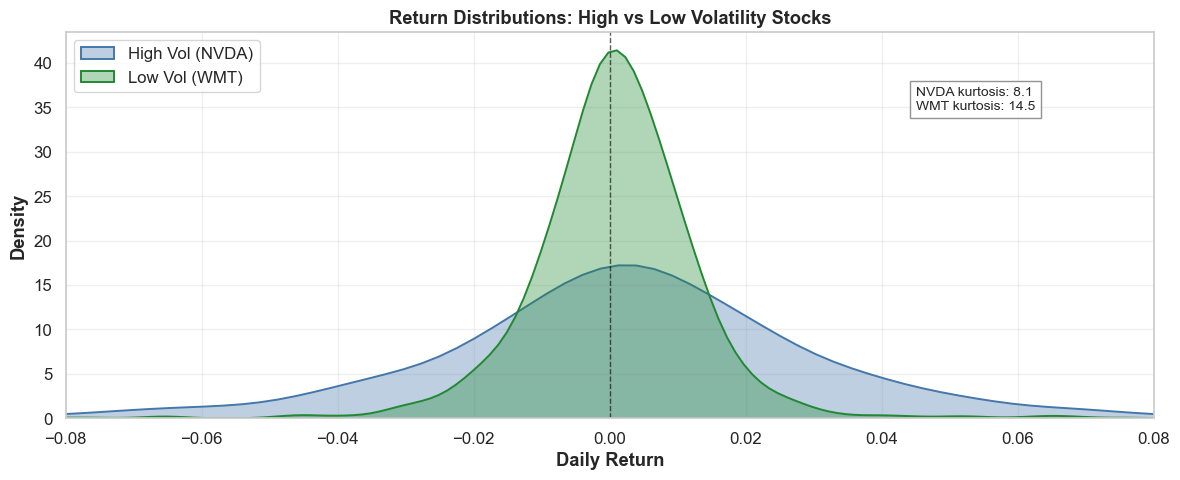

In [6]:
# Compare extreme cases: high-vol tech vs low-vol retail
example_tickers = ["NVDA", "WMT"]
colors = {"NVDA": "#4477AA", "WMT": "#228833"}

fig, ax = plt.subplots(figsize=(12, 5))
kurt_lines = []

for t in example_tickers:
    series = df[df["Ticker"] == t]["Return"].dropna()
    label = "High Vol (NVDA)" if t == "NVDA" else "Low Vol (WMT)"
    sns.kdeplot(series, ax=ax, fill=True, alpha=0.35, linewidth=1.4,
                color=colors[t], label=label)
    kurt_lines.append(f"{t} kurtosis: {stats.kurtosis(series, fisher=True):.1f}")

ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlim(-0.08, 0.08)
ax.set_title("Return Distributions: High vs Low Volatility Stocks", fontweight="bold")
ax.set_xlabel("Daily Return", fontweight="bold")
ax.set_ylabel("Density", fontweight="bold")
ax.legend(frameon=True, loc="upper left")
ax.grid(True, alpha=0.3)
ax.text(0.045, ax.get_ylim()[1] * 0.8, "\n".join(kurt_lines),
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray"), fontsize=10)

plt.tight_layout()
plt.show()

Both distributions are heavy-tailed. NVDA, the high-volatility growth stock, is much wider in
absolute terms with a daily standard deviation of 3.1% versus 1.4% for WMT. Relative to its own
scale, though, the stable retailer WMT has the heavier tails, showing excess kurtosis of 14.5
versus 8.1 for NVDA. The x-axis is clipped at plus or minus 8% for readability, so the most
extreme days (47 for NVDA alone) sit outside the plotted range.

### Cross-Ticker Correlations


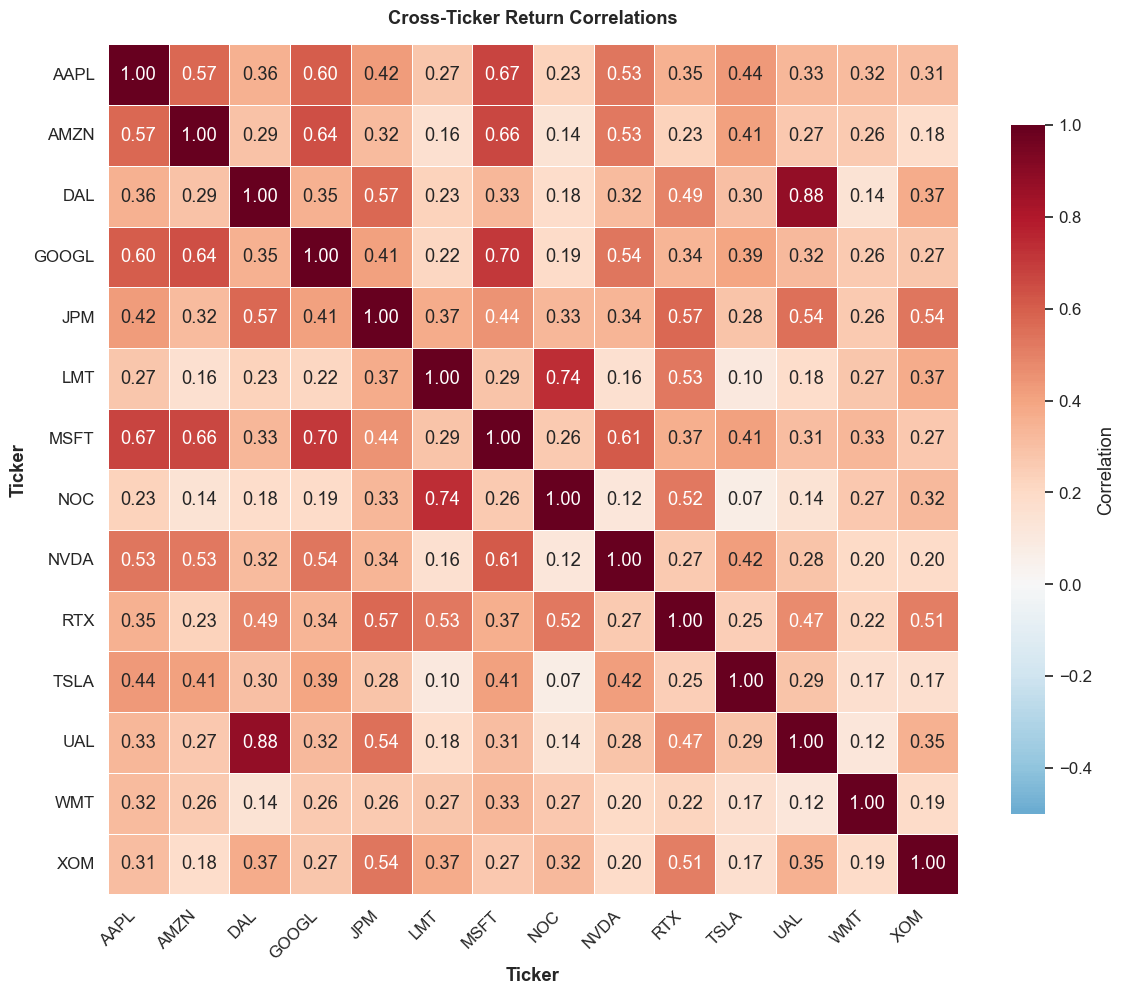


3 ticker pairs with r > 0.70:
  DAL and UAL: 0.88
  LMT and NOC: 0.74
  GOOGL and MSFT: 0.70

Median r: 0.32


In [7]:
# Pivot to wide format for correlation matrix
returns_wide = df.pivot(index="Date", columns="Ticker", values="Return")
ticker_corr = returns_wide.corr()

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(ticker_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.5, vmax=1.0,
            cbar_kws={"shrink": 0.8, "label": "Correlation"}, linewidths=0.5, ax=ax, square=True)
ax.set_title("Cross-Ticker Return Correlations", fontweight="bold", pad=15)
ax.set_xlabel("Ticker", fontweight="bold")
ax.set_ylabel("Ticker", fontweight="bold")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Flag pairs with strong co-movement (r > 0.70) for context
high_corr = []
for i in range(len(ticker_corr.columns)):
    for j in range(i+1, len(ticker_corr.columns)):
        r = ticker_corr.iloc[i, j]
        if r > 0.7:
            high_corr.append((ticker_corr.columns[i], ticker_corr.columns[j], r))

if high_corr:
    print(f"\n{len(high_corr)} ticker pairs with r > 0.70:")
    for t1, t2, r in sorted(high_corr, key=lambda x: x[2], reverse=True):
        print(f"  {t1} and {t2}: {r:.2f}")

median_corr = np.median(ticker_corr.values[np.triu_indices_from(ticker_corr.values, k=1)])
print(f"\nMedian r: {median_corr:.2f}")

Some tickers move together strongly (airlines especially strong), but most pairs are much less correlated. That suggests ticker identity still matters, and it’s worth checking that any model generalizes across names.

### Volatility by Ticker and Sector


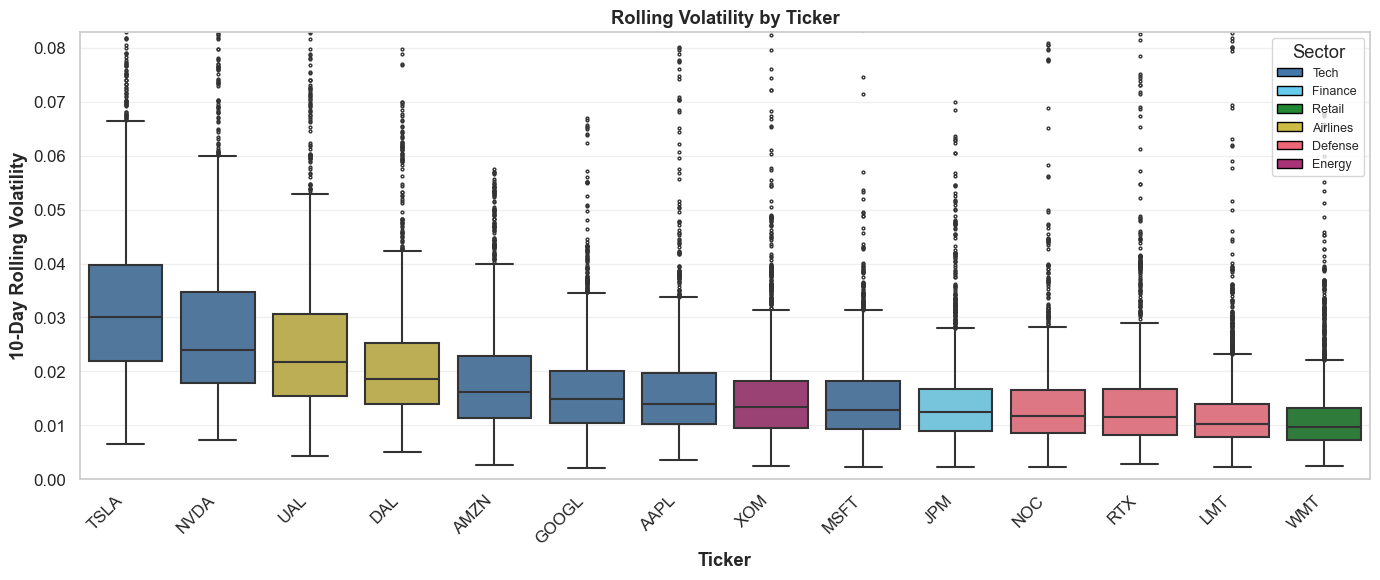

  Sector   median     mean      std
Airlines 0.020009 0.023982 0.016437
    Tech 0.017656 0.021132 0.013348
  Energy 0.013405 0.015213 0.008866
 Finance 0.012549 0.014498 0.009690
 Defense 0.011073 0.013302 0.008782
  Retail 0.009715 0.011656 0.007392


In [8]:
df_with_sector = df.copy()
df_with_sector["Sector"] = df_with_sector["Ticker"].map(sector_map)

# Map colors and sort tickers by median volatility (high to low)
ticker_palette = {t: sector_colors[sector_map[t]] for t in df["Ticker"].unique()}
ticker_order = df_with_sector.groupby("Ticker")["RollingVol"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(data=df_with_sector, x="Ticker", y="RollingVol", order=ticker_order,
            hue="Ticker", palette=ticker_palette, legend=False,
            ax=ax, linewidth=1.5, fliersize=2)
ax.set_title("Rolling Volatility by Ticker", fontweight="bold")
ax.set_xlabel("Ticker", fontweight="bold")
ax.set_ylabel("10-Day Rolling Volatility", fontweight="bold")
# Cap at 99.5th percentile to avoid extreme outliers stretching y-axis
ax.set_ylim(0, df_with_sector["RollingVol"].quantile(0.995))
ax.grid(True, alpha=0.3, axis="y")

# Add sector legend
legend_elements = [Patch(facecolor=color, label=sector, edgecolor="black") 
                   for sector, color in sector_colors.items()]
ax.legend(handles=legend_elements, loc="upper right", title="Sector", frameon=True, fontsize=9)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Summary stats by sector
sector_stats = (
    df_with_sector.groupby("Sector")["RollingVol"]
    .agg(["median", "mean", "std"])
    .sort_values("median", ascending=False)
    .reset_index()
)

print(sector_stats.to_string(index=False))

Airlines and growth tech stocks sit at the high end of the volatility spectrum; retail and finance stay relatively stable, and individual tickers still differ meaningfully within a sector.

## Target Selection

### Class Balance


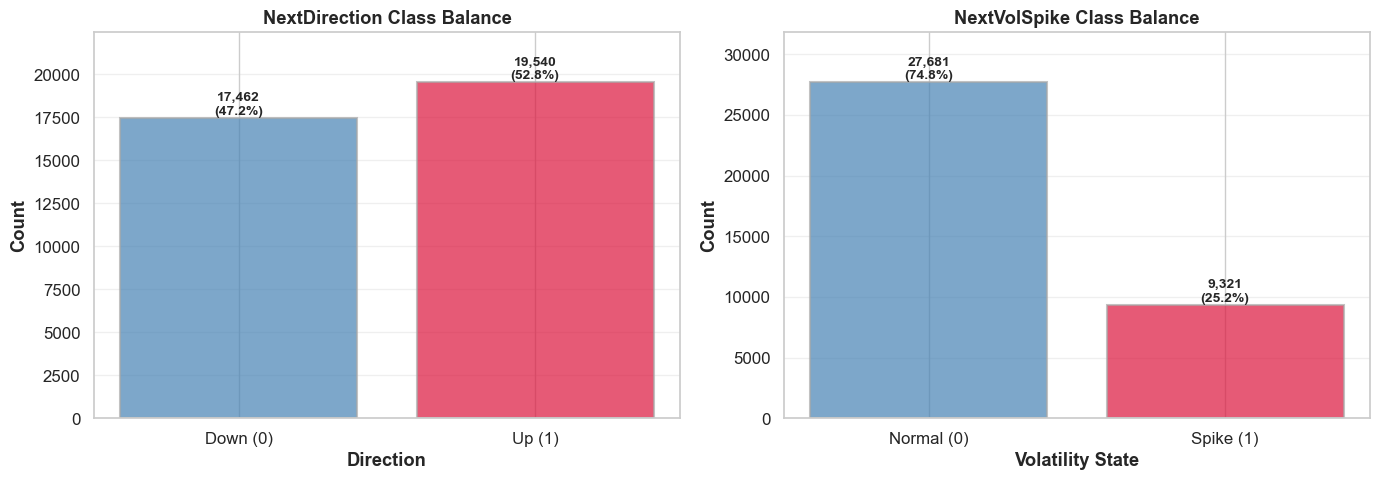


NextDirection: 19,540 up (52.8%), 17,462 down (47.2%)
NextVolSpike: 9,321 spikes (25.2%), 27,681 normal (74.8%)
Imbalance ratio: 3.0:1


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: NextDirection balance
dir_counts = df["NextDirection"].value_counts().reindex([0, 1], fill_value=0)
n_dir = dir_counts.sum()

ax1.bar(["Down (0)", "Up (1)"], dir_counts.values, color=["steelblue", "crimson"], 
        alpha=0.7, edgecolor="darkgrey", linewidth=1.5)
ax1.set_title("NextDirection Class Balance", fontweight="bold")
ax1.set_xlabel("Direction", fontweight="bold")
ax1.set_ylabel("Count", fontweight="bold")
ax1.set_ylim(0, dir_counts.max() * 1.15)
ax1.grid(True, alpha=0.3, axis="y")

# Add count labels with percentages
for i, v in enumerate(dir_counts.values):
    pct = v / n_dir * 100
    ax1.text(i, v + dir_counts.max() * 0.01, f"{v:,}\n({pct:.1f}%)", 
             ha="center", fontweight="bold", fontsize=10)

# Panel 2: NextVolSpike balance
vol_counts = df["NextVolSpike"].value_counts().reindex([0, 1], fill_value=0)
n_vol = vol_counts.sum()
imbalance_ratio = vol_counts[0] / vol_counts[1] if vol_counts[1] > 0 else np.nan

ax2.bar(["Normal (0)", "Spike (1)"], vol_counts.values, color=["steelblue", "crimson"],
        alpha=0.7, edgecolor="darkgrey", linewidth=1.5)
ax2.set_title("NextVolSpike Class Balance", fontweight="bold")
ax2.set_xlabel("Volatility State", fontweight="bold")
ax2.set_ylabel("Count", fontweight="bold")
ax2.set_ylim(0, vol_counts.max() * 1.15)
ax2.grid(True, alpha=0.3, axis="y")

for i, v in enumerate(vol_counts.values):
    pct = v / n_vol * 100
    ax2.text(i, v + vol_counts.max() * 0.01, f"{v:,}\n({pct:.1f}%)",
             ha="center", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nNextDirection: {dir_counts[1]:,} up ({dir_counts[1]/n_dir*100:.1f}%), {dir_counts[0]:,} down ({dir_counts[0]/n_dir*100:.1f}%)")
print(f"NextVolSpike: {vol_counts[1]:,} spikes ({vol_counts[1]/n_vol*100:.1f}%), {vol_counts[0]:,} normal ({vol_counts[0]/n_vol*100:.1f}%)")
print(f"Imbalance ratio: {imbalance_ratio:.1f}:1")


NextDirection comes in at 52.8% up days, so the bar for any direction model is always calling up, not 50%. NextVolSpike is imbalanced roughly 3 to 1, with spike days at 25.2% rather than the 20% the 80th-percentile threshold construction would suggest, because spikes cluster in crisis periods. Always calling normal already scores 74.8% accuracy on it, which is why the modeling notebook works with class weights, PR-AUC, and walk-forward splits rather than raw accuracy.

### Testing for Predictability


The two plots below check day-to-day dependence in returns versus volatility.

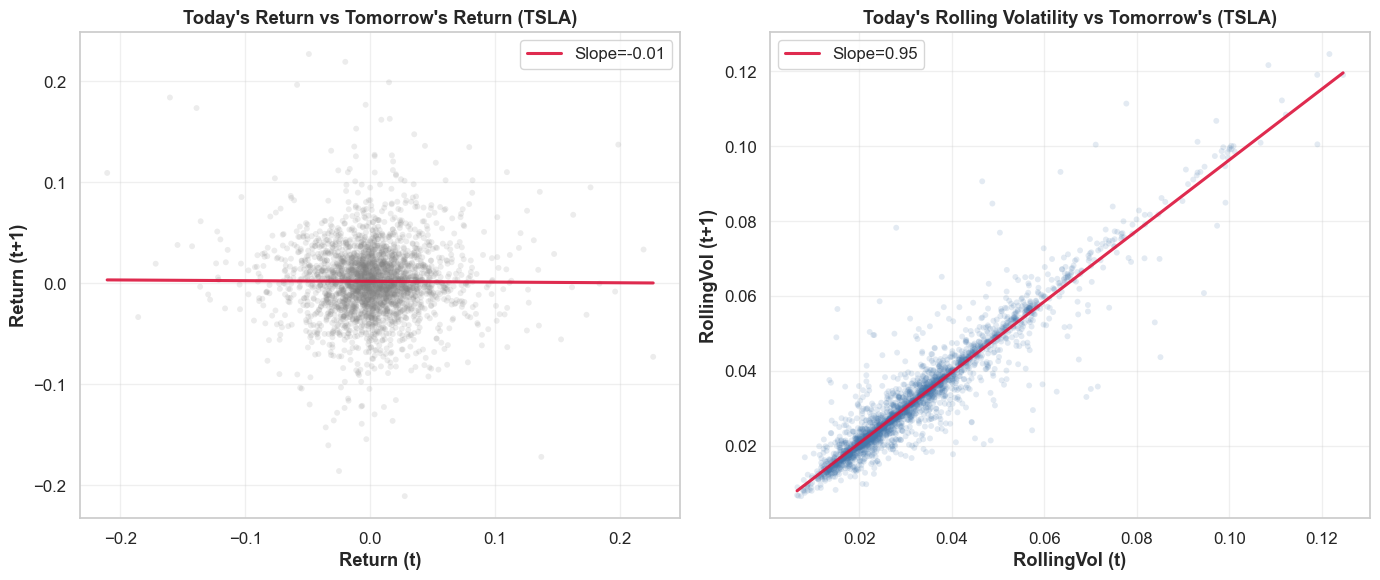

TSLA return autocorrelation: -0.007
TSLA volatility autocorrelation: 0.945


In [10]:
ticker = "TSLA"
ticker_color = sector_colors.get(sector_map.get(ticker, ""), "steelblue")

ticker_data = df_full[df_full["Ticker"] == ticker].sort_values("Date").copy()
# Create next-day values to test autocorrelation
ticker_data["NextReturn"] = ticker_data["Return"].shift(-1)
ticker_data["NextRollingVol"] = ticker_data["RollingVol"].shift(-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Direction (negative result)
dir_data = ticker_data[["Return", "NextReturn"]].dropna()
ax1.scatter(dir_data["Return"], dir_data["NextReturn"],
           color="gray", alpha=0.15, edgecolor="none", s=18)
if len(dir_data) > 2:
    m1, b1 = np.polyfit(dir_data["Return"], dir_data["NextReturn"], 1)
    x_line1 = np.linspace(dir_data["Return"].min(), dir_data["Return"].max(), 200)
    ax1.plot(x_line1, m1 * x_line1 + b1, color="crimson", linewidth=2.2,
            alpha=0.9, label=f"Slope={m1:.2f}")
ax1.set_title("Today's Return vs Tomorrow's Return (TSLA)", fontweight="bold")
ax1.set_xlabel("Return (t)", fontweight="bold")
ax1.set_ylabel("Return (t+1)", fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.legend(frameon=True)

# Panel 2: Volatility (positive result)
vol_data = ticker_data[["RollingVol", "NextRollingVol"]].dropna()
ax2.scatter(vol_data["RollingVol"], vol_data["NextRollingVol"],
           color=ticker_color, alpha=0.15, edgecolor="none", s=18)
if len(vol_data) > 2:
    m2, b2 = np.polyfit(vol_data["RollingVol"], vol_data["NextRollingVol"], 1)
    x_line2 = np.linspace(vol_data["RollingVol"].min(), vol_data["RollingVol"].max(), 200)
    ax2.plot(x_line2, m2 * x_line2 + b2, color="crimson", linewidth=2.2,
            alpha=0.9, label=f"Slope={m2:.2f}")
ax2.set_title("Today's Rolling Volatility vs Tomorrow's (TSLA)", fontweight="bold")
ax2.set_xlabel("RollingVol (t)", fontweight="bold")
ax2.set_ylabel("RollingVol (t+1)", fontweight="bold")
ax2.grid(True, alpha=0.3)
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()

if len(dir_data) > 2 and len(vol_data) > 2:
    print(f"{ticker} return autocorrelation: {dir_data['Return'].corr(dir_data['NextReturn']):.3f}")
    print(f"{ticker} volatility autocorrelation: {vol_data['RollingVol'].corr(vol_data['NextRollingVol']):.3f}")

Daily returns in the left panel scatter around zero with a nearly flat fit and a correlation of about -0.01 for TSLA. The fit uses one ticker and a one-day lag, and the autocorrelation figure below makes the same point across all 14 tickers.

Volatility in the right panel shows the opposite pattern. Consecutive 10-day rolling windows share 9 of their 10 days, so the roughly 0.94 correlation overstates true day-ahead persistence. The cleaner measure of clustering is the autocorrelation of absolute daily returns, around 0.24 at lag 1 and slow to decay. Either way volatility carries real information about tomorrow's volatility, which is why features like RollingVol and VIX drive the spike models.

### Volatility Persistence Across Tickers

Averaged across all 14 tickers, the autocorrelation of absolute daily returns (Cont 2001) is positive and decays only slowly (long memory), while raw returns sit near zero at every lag.

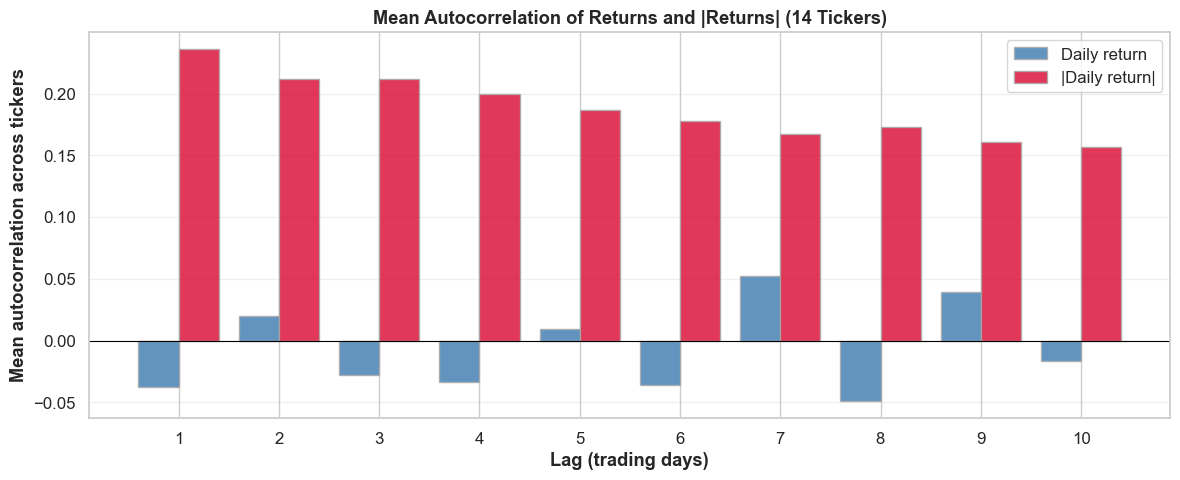

Lag-1 mean autocorrelation | Return: -0.038 | |Return|: 0.236


In [11]:
df["AbsReturn"] = df["Return"].abs()
lags = range(1, 11)

def mean_acf(col):
    rows = []
    for _, g in df.groupby("Ticker"):
        s = g.sort_values("Date")[col].dropna()
        rows.append([s.autocorr(lag=k) for k in lags])
    return np.nanmean(rows, axis=0)

acf_ret = mean_acf("Return")
acf_absret = mean_acf("AbsReturn")

x = np.arange(1, 11)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 0.2, acf_ret, 0.4, label="Daily return", color="#4682B4", alpha=0.85, edgecolor="darkgrey")
ax.bar(x + 0.2, acf_absret, 0.4, label="|Daily return|", color="#DC143C", alpha=0.85, edgecolor="darkgrey")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xlabel("Lag (trading days)", fontweight="bold")
ax.set_ylabel("Mean autocorrelation across tickers", fontweight="bold")
ax.set_title("Mean Autocorrelation of Returns and |Returns| (14 Tickers)", fontweight="bold")
ax.legend(frameon=True)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"Lag-1 mean autocorrelation | Return: {acf_ret[0]:.3f} | |Return|: {acf_absret[0]:.3f}")

### Feature Signal by VIX Decile

Autocorrelation is about the target's own past. It also helps to check that the input features separate spike days from calm days. Grouping every day by its VIX decile, the next-day spike rate rises strongly from the low-VIX deciles to the high-VIX deciles, which is direct evidence that market stress carries predictive information.

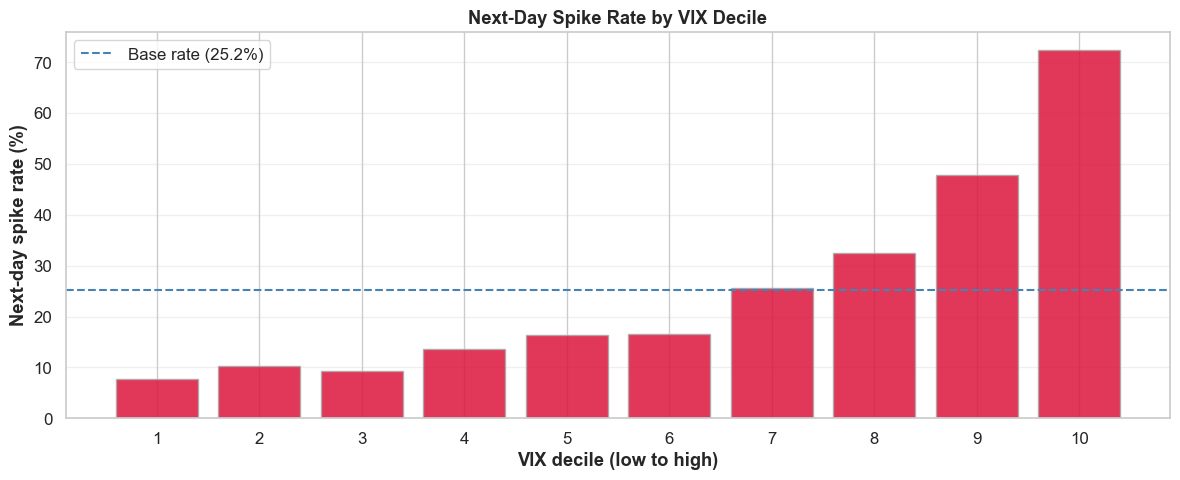

Spike rate: low-VIX decile 7.7% -> high-VIX decile 72.3%


In [12]:
vix_decile = pd.qcut(df["VIX"], 10, labels=False)
spike_by_vix = df.groupby(vix_decile)["NextVolSpike"].mean() * 100
base_rate = df["NextVolSpike"].mean() * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(spike_by_vix.index + 1, spike_by_vix.values, color="#DC143C", alpha=0.85, edgecolor="darkgrey")
ax.axhline(base_rate, color="#4682B4", linestyle="--", linewidth=1.5, label=f"Base rate ({base_rate:.1f}%)")
ax.set_xticks(range(1, 11))
ax.set_xlabel("VIX decile (low to high)", fontweight="bold")
ax.set_ylabel("Next-day spike rate (%)", fontweight="bold")
ax.set_title("Next-Day Spike Rate by VIX Decile", fontweight="bold")
ax.legend(frameon=True)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"Spike rate: low-VIX decile {spike_by_vix.iloc[0]:.1f}% -> high-VIX decile {spike_by_vix.iloc[-1]:.1f}%")

NextVolSpike is the primary modeling target because it shows autocorrelation and ties to market
stress cycles. NextDirection served as an EDA-level negative control and is not carried into
modeling.

The modeling notebook refines this next-day target into a forward-disjoint 10-day regime target for the main results. See `02_modeling`.

## Crisis Period Analysis

Volatility clusters in time, so this section examines when and why those clusters occur. It validates the
spike labels against the threshold rule and shows how average volatility varies over time. The
tie to macro stress runs through the VIX decile analysis in the previous section.

### Label Validation


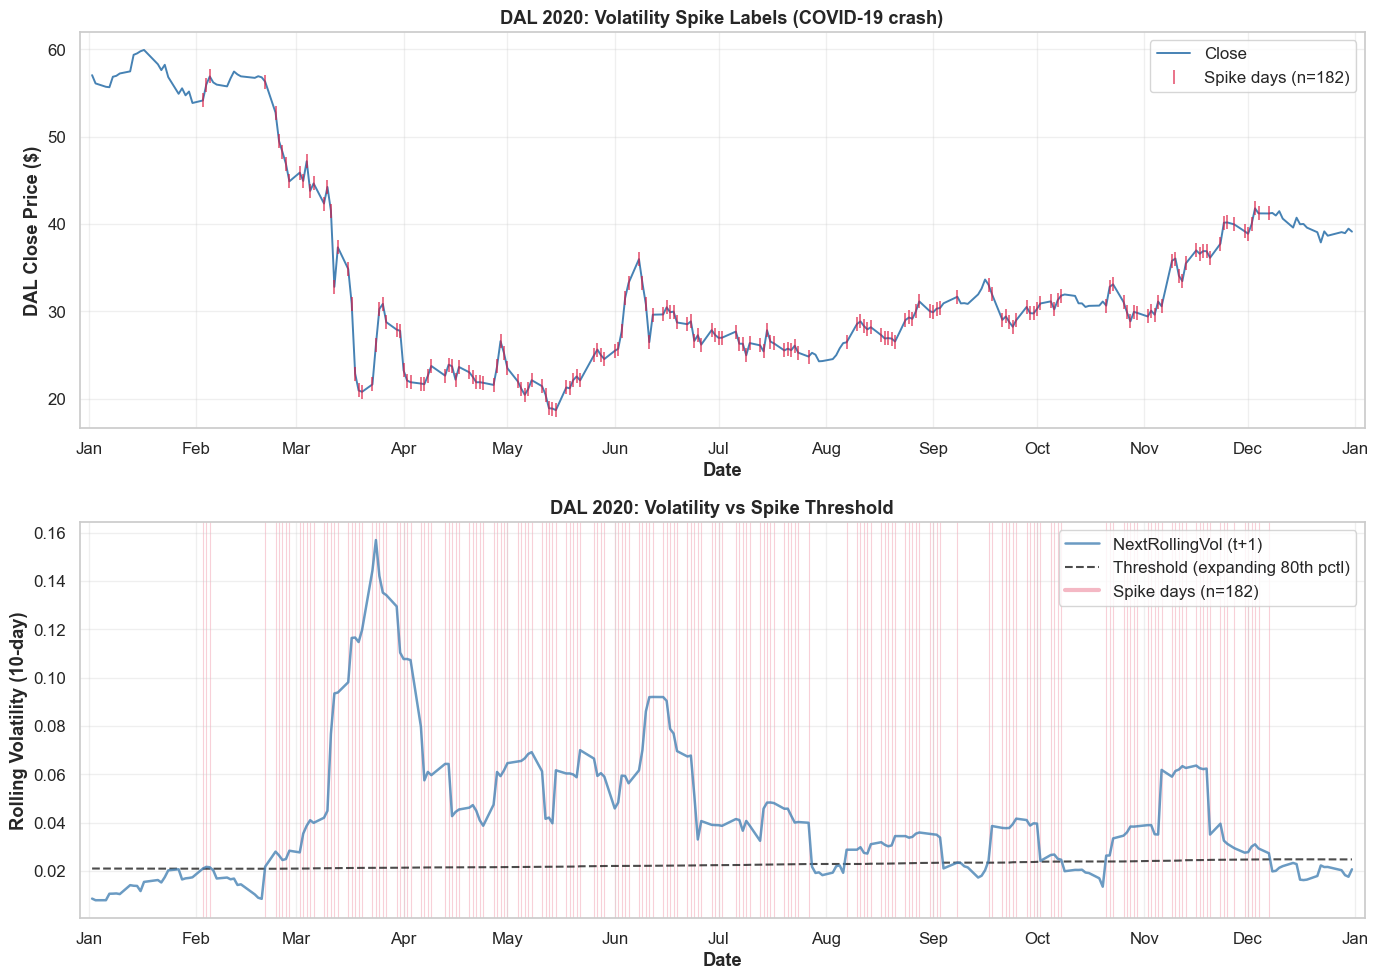


DAL 2020 (COVID-19 crash):
  Label validation: 0 mismatches out of 253 days
  All labels consistent with threshold rule
  182 spikes (71.9%), price $18.67-$59.93



In [13]:
# Validate labels against the threshold rule during the COVID-19 crash
ticker, year, crisis_name = "DAL", 2020, "COVID-19 crash"

# Compute threshold on full history, then slice to year
ticker_data = df_full[df_full["Ticker"] == ticker].sort_values("Date").copy()
ticker_data["VolThreshold"] = ticker_data["RollingVol"].shift(1).expanding(min_periods=126).quantile(0.8)
ticker_data["NextRollingVol"] = ticker_data["RollingVol"].shift(-1)
ticker_data["ImpliedSpike"] = (ticker_data["NextRollingVol"] > ticker_data["VolThreshold"]).astype(int)

year_data = ticker_data[ticker_data["Date"].dt.year == year].copy()


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [1, 1]})

# Panel 1: Price with spike markers
spike_mask = year_data["NextVolSpike"] == 1
n_spikes = spike_mask.sum()

ax1.plot(year_data["Date"], year_data["Close"], color="steelblue", linewidth=1.4, label="Close")
ax1.plot(year_data.loc[spike_mask, "Date"], year_data.loc[spike_mask, "Close"],
         marker="|", markersize=10, linestyle="", color="crimson", alpha=0.7, 
         markeredgewidth=1.2, label=f"Spike days (n={n_spikes})", zorder=3)
ax1.set_xlabel("Date", fontweight="bold")
ax1.set_ylabel(f"{ticker} Close Price ($)", fontweight="bold")
ax1.set_title(f"{ticker} {year}: Volatility Spike Labels ({crisis_name})", fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right", frameon=True)
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax1.margins(x=0.01)

# Panel 2: Volatility mechanics
ax2.plot(year_data["Date"], year_data["NextRollingVol"], color="steelblue", linewidth=1.8, 
         alpha=0.8, label="NextRollingVol (t+1)", zorder=2)
ax2.plot(year_data["Date"], year_data["VolThreshold"], color="black", linestyle="--", 
         linewidth=1.5, alpha=0.7, label="Threshold (expanding 80th pctl)", zorder=1)

# Shade spike days
for date in year_data.loc[spike_mask, "Date"]:
    ax2.axvline(date, color="crimson", alpha=0.2, linewidth=0.8, zorder=0)

# Add dummy line for legend
ax2.plot([], [], color="crimson", alpha=0.3, linewidth=3, label=f"Spike days (n={n_spikes})")

ax2.set_xlabel("Date", fontweight="bold")
ax2.set_ylabel("Rolling Volatility (10-day)", fontweight="bold")
ax2.set_title(f"{ticker} {year}: Volatility vs Spike Threshold", fontweight="bold")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right", frameon=True)
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax2.margins(x=0.01)

plt.tight_layout()
plt.show()

# Verify the stored spike labels match the threshold rule
valid = year_data[year_data["NextVolSpike"].notna() & year_data["ImpliedSpike"].notna()]
mismatches = (valid["NextVolSpike"] != valid["ImpliedSpike"]).sum()

print(f"\n{ticker} {year} ({crisis_name}):")
print(f"  Label validation: {mismatches} mismatches out of {len(valid)} days")
if mismatches == 0:
    print("  All labels consistent with threshold rule")

spike_rate = spike_mask.mean() * 100
print(f"  {n_spikes} spikes ({spike_rate:.1f}%), price ${year_data['Close'].min():.2f}-${year_data['Close'].max():.2f}")
print()

The label validation above confirms two things:
- The spike threshold is based only on history through the prior day, with no forward information
- Spikes line up with obvious stress windows

DAL in 2020 is a clear example. The COVID crash produces a dense cluster of spike days exactly where volatility jumps above its historical threshold.

### Volatility Over Time


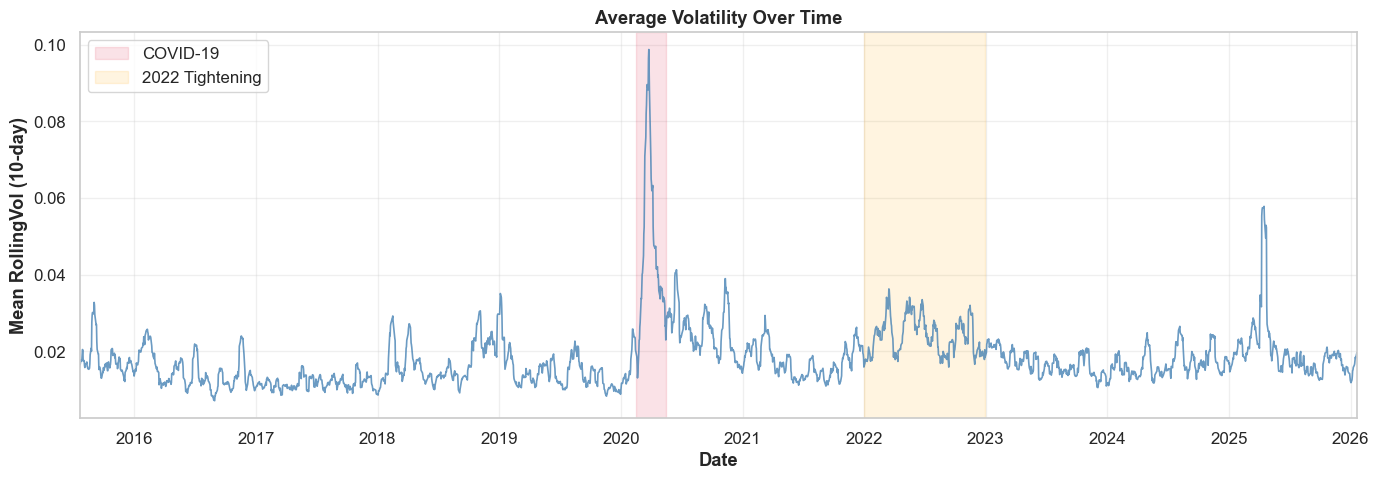

Baseline: 0.0161, COVID peak: 0.0987 (6.1x)


In [14]:
daily_avg_vol = df.groupby("Date")["RollingVol"].mean().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(daily_avg_vol.index, daily_avg_vol.values, color="steelblue", alpha=0.8, linewidth=1.2)

# Highlight known crisis periods
ax.axvspan(pd.to_datetime("2020-02-15"), pd.to_datetime("2020-05-15"),
           color="crimson", alpha=0.12, label="COVID-19")
ax.axvspan(pd.to_datetime("2022-01-01"), pd.to_datetime("2022-12-31"),
           color="orange", alpha=0.12, label="2022 Tightening")

ax.set_title("Average Volatility Over Time", fontweight="bold")
ax.set_xlabel("Date", fontweight="bold")
ax.set_ylabel("Mean RollingVol (10-day)", fontweight="bold")
ax.legend(frameon=True, loc="upper left")
ax.grid(True, alpha=0.3)
ax.margins(x=0)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

# Quantify crisis impact
start_date = pd.to_datetime("2020-02-15")
end_date = pd.to_datetime("2020-05-15")
covid_vol = daily_avg_vol[(daily_avg_vol.index >= start_date) & (daily_avg_vol.index <= end_date)]
baseline_vol = daily_avg_vol[(daily_avg_vol.index < start_date) | (daily_avg_vol.index > pd.to_datetime("2022-12-31"))]

print(f"Baseline: {baseline_vol.mean():.4f}, COVID peak: {covid_vol.max():.4f} ({covid_vol.max() / baseline_vol.mean():.1f}x)")

The COVID window and the 2022 tightening cycle stand out against calmer stretches, and the
unshaded spring 2025 spike runs second only to COVID, well above the 2022 peak. This
persistence is why validation is time-based and why spike precision and recall matter more than
accuracy.

## Feature Assessment

This final section checks for multicollinearity among predictors and confirms the features are ready for modeling.


### Multicollinearity


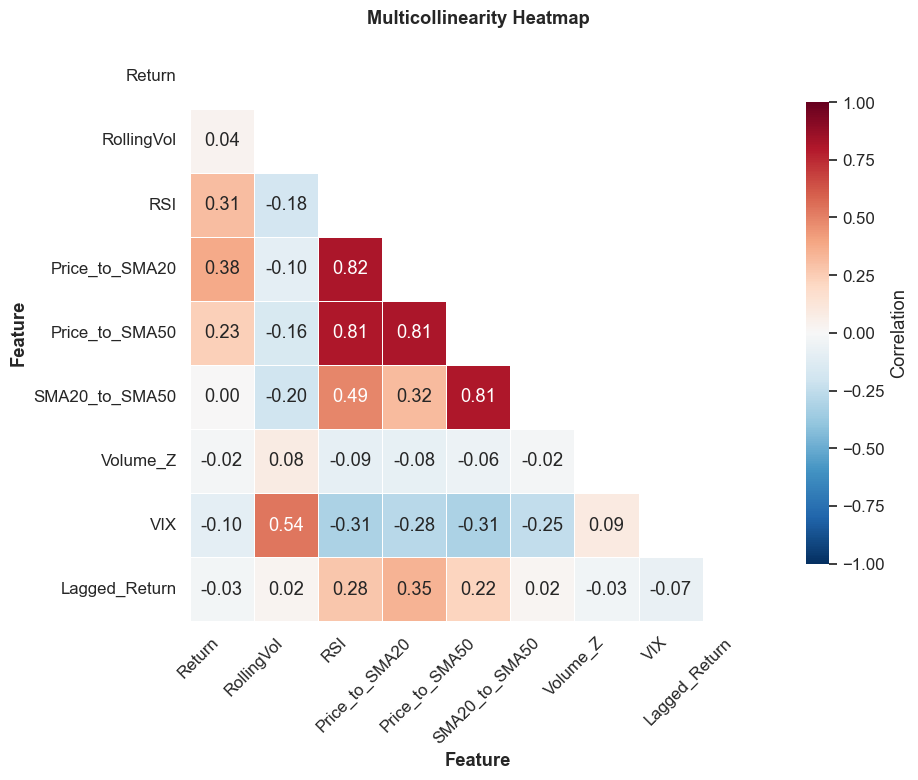

In [15]:
feature_cols = ['Return', 'RollingVol', 'RSI', 'Price_to_SMA20', 'Price_to_SMA50',
                'SMA20_to_SMA50', 'Volume_Z', 'VIX', 'Lagged_Return']

feature_corr = df[feature_cols].corr()

# Upper triangle mask to avoid redundancy
mask = np.triu(np.ones_like(feature_corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(feature_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'}, linewidths=0.5, ax=ax, square=True)
ax.set_title('Multicollinearity Heatmap', fontweight='bold', pad=15)
ax.set_xlabel('Feature', fontweight='bold')
ax.set_ylabel('Feature', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
# Remove background grid for clean heatmap
ax.grid(False)
plt.tight_layout()
plt.show()

Several SMA-style features overlap heavily, which is expected. Regularization and the
linear-vs-tree comparison in `02_modeling`, plus the SHAP feature-importance check in
`03_explainability`, guard against keeping redundant signals.


## Summary

Direction shows little exploitable signal: up days barely edge past a coin flip and return-to-return dependence sits near zero. Volatility is the opposite. Absolute-return autocorrelation is positive and decays slowly, spikes cluster in stress periods like 2020, 2022, and spring 2025, and VIX moves with realized volatility. That makes volatility the target worth modeling and macro stress indicators worth including.

**Modeling handoff**
- **NextVolSpike** carries forward as the spike target, and the modeling notebook promotes its forward 10-day version to primary
- Validation is walk-forward / expanding-window, with no random splits
- Metrics are spike precision, recall, and PR-AUC rather than accuracy alone, since always predicting normal catches zero spikes
- The models are a regularized linear baseline and two gradient-boosted tree models, compared for stability across time splits